In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow import keras

# Set Datalist

In [26]:
file_path = r'C:\Users\sharif\Desktop\Final5.xlsx'
df = pd.read_excel(file_path)
df.head()

,"STREAMS(""METHANOL"").F","STREAMS(""METHANOL"").T","STREAMS(""METHANOL"").P","STREAMS(""FV"").F","STREAMS(""FV"").T","STREAMS(""FV"").P","STREAMS(""FV"").Zmn(""1-BUT-01"")","STREAMS(""FV"").Zmn(""ISOBU-01"")","STREAMS(""P1"").F","STREAMS(""P1"").T",...,"BLOCKS(""RDCOLUMN"").Stage(4).T","BLOCKS(""RDCOLUMN"").Stage(5).T","BLOCKS(""RDCOLUMN"").Stage(6).T","BLOCKS(""RDCOLUMN"").Stage(7).T","BLOCKS(""RDCOLUMN"").Stage(8).T","BLOCKS(""RDCOLUMN"").Stage(9).T","BLOCKS(""RDCOLUMN"").Stage(10).T","BLOCKS(""RDCOLUMN"").Stage(11).T","STREAMS(""P1"").Zmn(""1-BUT-01"")","STREAMS(""P2"").Zmn(""METHY-01"")"
0,712.082,46.85,1.01325,1965.0,178.574,12.1592,0.64,0.36,1340.14,76.3314,...,105.113,115.106,120.103,122.286,123.236,123.67,123.896,128.634,0.936555,0.965974
1,712.082,46.85,1.01325,1965.0,178.574,12.1592,0.64,0.36,1340.14,76.3314,...,105.113,115.106,120.103,122.286,123.236,123.67,123.896,128.634,0.936555,0.965974
2,712.082,46.85,1.01325,1965.0,178.574,12.1592,0.64,0.36,1340.14,76.3314,...,105.113,115.106,120.103,122.286,123.236,123.67,123.896,128.634,0.936555,0.965974
3,712.082,46.85,1.01325,1965.0,178.574,12.1592,0.64,0.36,1340.14,76.3314,...,105.113,115.106,120.103,122.286,123.236,123.67,123.896,128.634,0.936555,0.965974
4,712.082,46.85,1.01325,1965.0,178.574,12.1592,0.64,0.36,1340.14,76.3313,...,105.113,115.106,120.103,122.286,123.236,123.67,123.896,128.634,0.936555,0.965974


In [27]:
df.describe

<bound method NDFrame.describe of        STREAMS("METHANOL").F  STREAMS("METHANOL").T  STREAMS("METHANOL").P  \
0                    712.082                  46.85                1.01325   
1                    712.082                  46.85                1.01325   
2                    712.082                  46.85                1.01325   
3                    712.082                  46.85                1.01325   
4                    712.082                  46.85                1.01325   
...                      ...                    ...                    ...   
12648                718.993                  46.85                1.01325   
12649                718.993                  46.85                1.01325   
12650                718.993                  46.85                1.01325   
12651                718.993                  46.85                1.01325   
12652                718.993                  46.85                1.01325   

       STREAMS("FV").F  STREA

# PreProcessing

In [28]:
x = df.drop(['STREAMS("P2").Zmn("METHY-01")','STREAMS("P1").Zmn("1-BUT-01")'] , axis=1).values
y = df[['STREAMS("P2").Zmn("METHY-01")','STREAMS("P1").Zmn("1-BUT-01")']].values

In [29]:
x.shape , y.shape

((12653, 36), (12653, 2))

In [30]:
x

array([[712.082  ,  46.85   ,   1.01325, ..., 123.67   , 123.896  ,
        128.634  ],
       [712.082  ,  46.85   ,   1.01325, ..., 123.67   , 123.896  ,
        128.634  ],
       [712.082  ,  46.85   ,   1.01325, ..., 123.67   , 123.896  ,
        128.634  ],
       ...,
       [718.993  ,  46.85   ,   1.01325, ..., 106.044  , 104.518  ,
        107.674  ],
       [718.993  ,  46.85   ,   1.01325, ..., 106.044  , 104.518  ,
        107.674  ],
       [718.993  ,  46.85   ,   1.01325, ..., 106.044  , 104.518  ,
        107.674  ]], shape=(12653, 36))

In [31]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

In [32]:
x_train.shape , x_test.shape ,x_val.shape , y_train.shape , y_test.shape , y_val.shape

((8097, 36), (2531, 36), (2025, 36), (8097, 2), (2531, 2), (2025, 2))

In [33]:
x_train[1]

array([ 4.63555e+02,  4.68500e+01,  1.01325e+00,  1.96500e+03,
        1.78095e+02,  1.20003e+01,  7.50000e-01,  2.50000e-01,
        1.57046e+03,  7.63062e+01,  1.11449e+01,  4.42318e+02,
        1.49615e+02,  1.18778e+01,  1.11449e+01, -3.68046e+01,
        7.63062e+01,  2.21509e+01,  7.51999e+03,  1.11449e+01,
        7.63062e+01,  4.78840e+00,  1.37503e+00,  1.49615e+02,
        1.11449e+01,  1.12387e+01,  1.16203e+01,  1.18778e+01,
        1.03344e+02,  1.12917e+02,  1.17683e+02,  1.19766e+02,
        1.20693e+02,  1.21150e+02,  1.21419e+02,  1.27347e+02])

In [34]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)
x_test = scaler.transform(x_test)

In [35]:
x_train[1]

array([7.07445376e-04, 5.00000000e-01, 5.00000000e-01, 5.15625000e-01,
       4.48039114e-01, 2.41037766e-01, 1.00000000e+00, 0.00000000e+00,
       9.99465411e-01, 4.84860437e-01, 4.45049218e-01, 2.94280297e-01,
       6.84233943e-01, 1.70623396e-01, 4.45049218e-01, 6.94682699e-01,
       4.84868830e-01, 3.17837537e-01, 2.58760915e-01, 4.45049218e-01,
       4.84860437e-01, 2.01560234e-14, 8.93924475e-02, 6.84233943e-01,
       4.45049218e-01, 4.05940902e-01, 2.41032632e-01, 1.70623396e-01,
       6.55913025e-01, 8.17083264e-01, 8.84496498e-01, 9.11650397e-01,
       9.14240984e-01, 9.05924764e-01, 8.99956138e-01, 9.27498851e-01])

# Model Definition

In [36]:
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import KFold, GridSearchCV
from scikeras .wrappers import KerasRegressor

model = keras.Sequential()

model.add (keras.layers.Input(shape=(36,)))

model.add (keras.layers.Dense(units = 128 , activation = 'relu'))
model.add(BatchNormalization())
model.add(Dropout(0.1))



model.add (keras.layers.Dense(units = 64 , activation = 'relu'))
model.add(BatchNormalization())
model.add(Dropout(0.1))

model.add (keras.layers.Dense(units = 2 , activation = 'linear'))
optimizer = Adam(learning_rate=0.0001)

model.compile(optimizer = optimizer , loss = 'mse' , metrics = ['mae'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,890 (54.26 KB)

 Trainable params: 13,506 (52.76 KB)

 Non-trainable params: 384 (1.50 KB)

In [37]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=65, restore_best_weights=True)

In [38]:
hist = model.fit(x_train, y_train, epochs=500, batch_size=36, validation_data=(x_val, y_val), callbacks=[early_stop])

Epoch 1/500
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 1.5342 - mae: 1.0373 - val_loss: 1.3898 - val_mae: 1.1639
Epoch 2/500
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.9934 - mae: 0.8432 - val_loss: 0.9601 - val_mae: 0.9665
Epoch 3/500
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.7540 - mae: 0.7267 - val_loss: 0.3920 - val_mae: 0.6071
Epoch 4/500
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.5558 - mae: 0.6165 - val_loss: 0.2451 - val_mae: 0.4728
Epoch 5/500
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.4234 - mae: 0.5277 - val_loss: 0.1314 - val_mae: 0.3450
Epoch 6/500
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.3237 - mae: 0.4492 - val_loss: 0.0660 - val_mae: 0.2378
Epoch 7/500
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2608 - mae: 0.3967 - val_loss: 0.0520 - val_mae: 0.2147
Epoch 8/500
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2156 - mae: 0.3585 - val_loss: 0.0314 - val_mae: 0.1627
Epoch 9/500
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8m

# Evaluate on test data

In [39]:
test_loss, test_mae = model.evaluate(x_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test MAE: {test_mae}")

80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.9173e-06 - mae: 0.0018
Test Loss: 7.901249773567542e-06
Test MAE: 0.001765427296049893


In [40]:
y_pred = model.predict(x_test)

80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [41]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse}")
print(f"MAE: {mae}")
print(f"R2 Score: {r2}")

MSE: 7.901246910767319e-06
MAE: 0.001765427328260455
R2 Score: 0.9839830107855858


In [42]:
errors = np.abs(y_test - y_pred)
print("Max error:", np.max(errors))

Max error: 0.04045835936737063


In [43]:
results = pd.DataFrame({
    'Actual MoleFractionTX': y_test[:, 0],
    'Predicted MoleFractionTX': y_pred[:, 0],
    'Actual MoleFractionHX': y_test[:, 1],
    'Predicted MoleFractionHX': y_pred[:, 1]
})

results.head()

,Actual MoleFractionTX,Predicted MoleFractionTX,Actual MoleFractionHX,Predicted MoleFractionHX
0,0.965668,0.967628,0.937514,0.936125
1,0.727290,0.723520,0.941283,0.940515
2,0.965202,0.967339,0.934364,0.934442
3,0.965974,0.967518,0.936495,0.935105
4,0.960999,0.962469,0.940697,0.940681


Total number of samples: 2531
Plotting first 5000 samples.


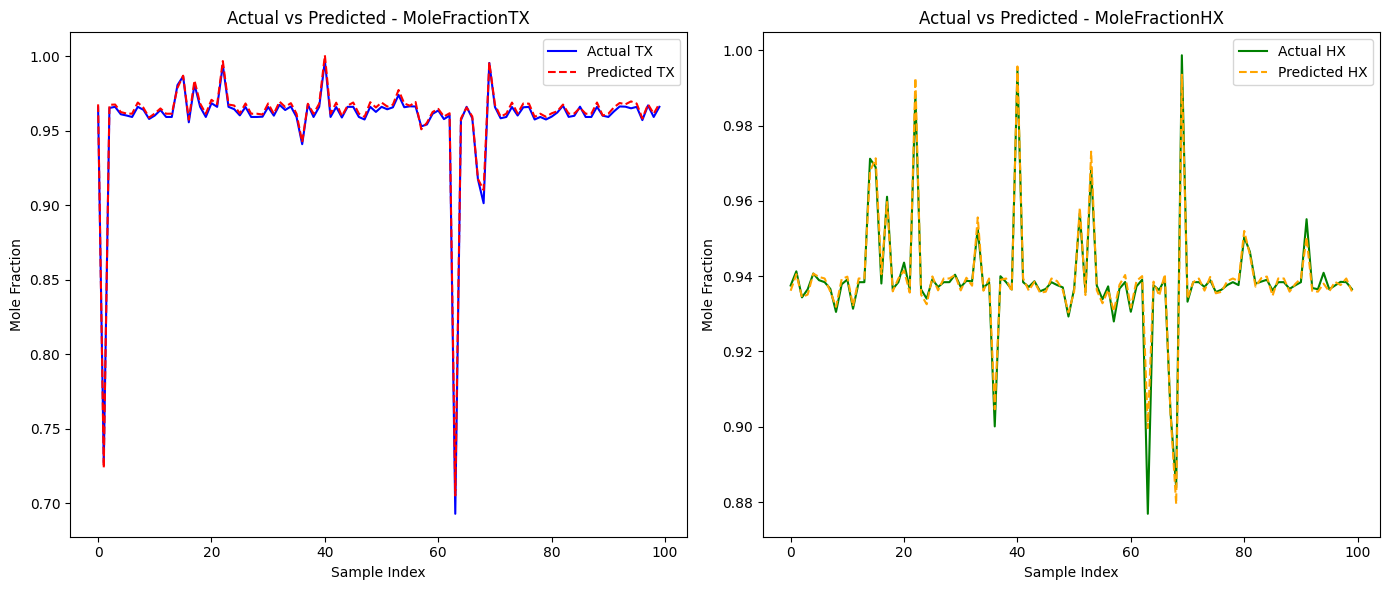

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# بررسی تعداد کل داده‌ها
num_samples = len(results)
print(f"Total number of samples: {num_samples}")

# اگر داده‌ها بیشتر از 5000 بودند، فقط 5000 تای اول را انتخاب کن
if num_samples >= 100:
    subset = results.iloc[:100]
    print("Plotting first 5000 samples.")
else:
    subset = results
    print("Plotting all available samples.")

# رسم نمودار
plt.figure(figsize=(14, 6))

# MoleFractionTX
plt.subplot(1, 2, 1)
plt.plot(subset['Actual MoleFractionTX'].values, label='Actual TX', color='blue')
plt.plot(subset['Predicted MoleFractionTX'].values, label='Predicted TX', color='red', linestyle='--')
plt.title('Actual vs Predicted - MoleFractionTX')
plt.xlabel('Sample Index')
plt.ylabel('Mole Fraction')
plt.legend()

# MoleFractionHX
plt.subplot(1, 2, 2)
plt.plot(subset['Actual MoleFractionHX'].values, label='Actual HX', color='green')
plt.plot(subset['Predicted MoleFractionHX'].values, label='Predicted HX', color='orange', linestyle='--')
plt.title('Actual vs Predicted - MoleFractionHX')
plt.xlabel('Sample Index')
plt.ylabel('Mole Fraction')
plt.legend()

plt.tight_layout()
plt.show()

In [45]:
def percentage_within_tolerance(y_true, y_pred, tolerance):
    diff = np.abs(y_true - y_pred)
    within_tol = np.sum(diff <= tolerance)
    return (within_tol / len(y_true)) * 100

In [46]:
tolerances = [0.005, 0.001, 0.002]

# دو خروجی داریم: TX (ستون 0) و HX (ستون 1)
tx_true = y_test[:, 0]
tx_pred = y_pred[:, 0]
hx_true = y_test[:, 1]
hx_pred = y_pred[:, 1]

tx_results = []
hx_results = []

In [47]:
for tol in tolerances:
    tx_acc = percentage_within_tolerance(tx_true, tx_pred, tolerance=tol)
    hx_acc = percentage_within_tolerance(hx_true, hx_pred, tolerance=tol)
    tx_results.append(tx_acc)
    hx_results.append(hx_acc)
    print(f"TX - درصد پیش‌بینی‌ها با اختلاف ≤ ±{tol}: {tx_acc:.2f}%")
    print(f"HX - درصد پیش‌بینی‌ها با اختلاف ≤ ±{tol}: {hx_acc:.2f}%")
    print('-'*50)

TX - درصد پیش‌بینی‌ها با اختلاف ≤ ±0.005: 95.97%
HX - درصد پیش‌بینی‌ها با اختلاف ≤ ±0.005: 97.08%
--------------------------------------------------
TX - درصد پیش‌بینی‌ها با اختلاف ≤ ±0.001: 14.90%
HX - درصد پیش‌بینی‌ها با اختلاف ≤ ±0.001: 64.64%
--------------------------------------------------
TX - درصد پیش‌بینی‌ها با اختلاف ≤ ±0.002: 45.99%
HX - درصد پیش‌بینی‌ها با اختلاف ≤ ±0.002: 85.34%
--------------------------------------------------


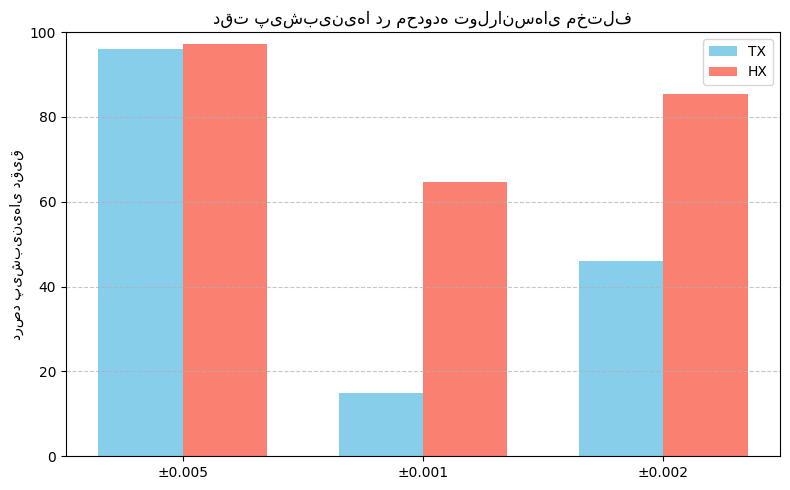

In [48]:
x_labels = [f"±{tol}" for tol in tolerances]
x = np.arange(len(tolerances))

plt.figure(figsize=(8, 5))
bar_width = 0.35

plt.bar(x - bar_width/2, tx_results, width=bar_width, label='TX', color='skyblue')
plt.bar(x + bar_width/2, hx_results, width=bar_width, label='HX', color='salmon')

plt.xticks(x, x_labels)
plt.ylim(0, 100)
plt.ylabel("درصد پیش‌بینی‌های دقیق")
plt.title("دقت پیش‌بینی‌ها در محدوده تولرانس‌های مختلف")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

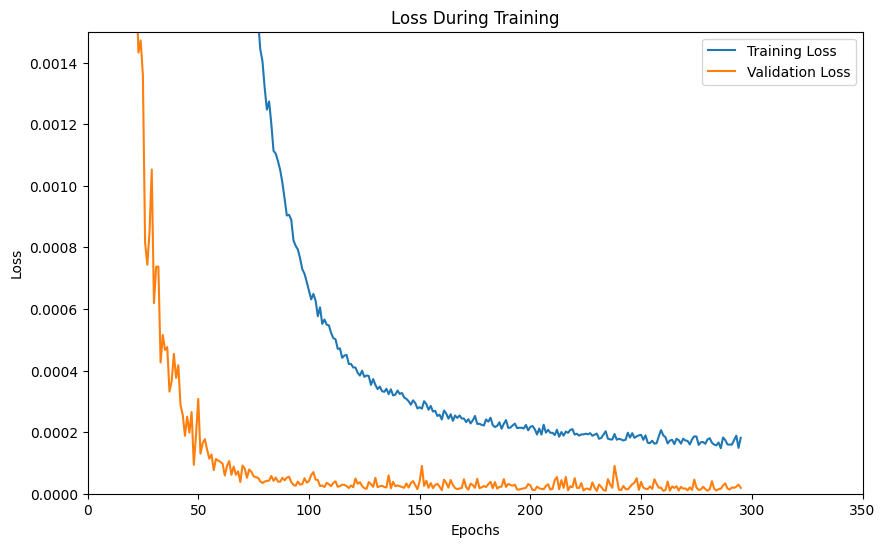

In [49]:
plt.figure(figsize=(10, 6))
plt.plot(hist.history['loss'], label='Training Loss')
plt.plot(hist.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss During Training')
plt.legend()
plt.xlim(0,350)
plt.ylim(0,0.00150)
plt.show()

In [50]:
import shap

d:\ArshadProjectVSCode\final\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [51]:
x_sample = x_train[np.random.choice(x_train.shape[0], size=100, replace=False)]

In [52]:
explainer = shap.Explainer(model, x_sample)

In [53]:
shap_values = explainer(x_test[:2000])

PermutationExplainer explainer: 2001it [05:52,  5.67it/s]                          



Feature importance for output 1


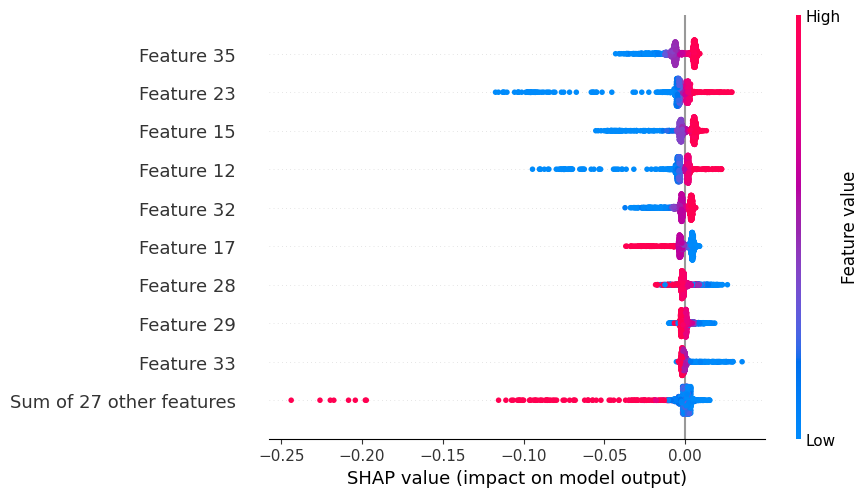


Feature importance for output 2


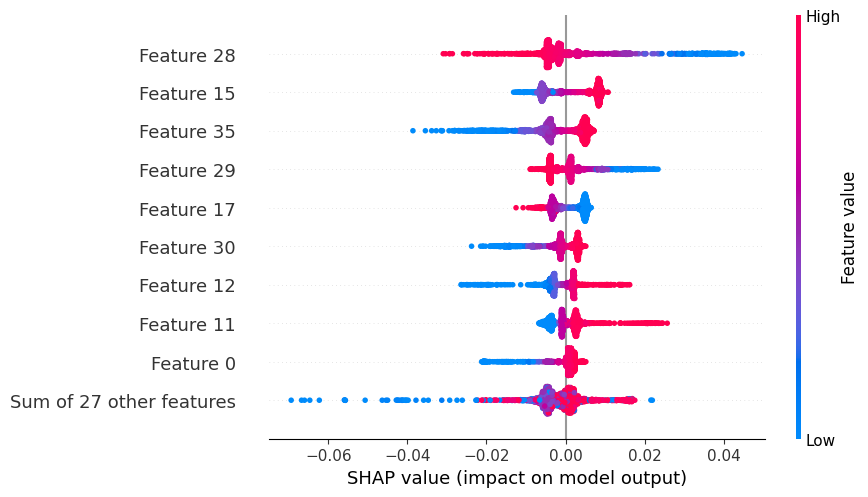

In [54]:
for i in range(2):  # برای هر خروجی جداگانه
    print(f"\nFeature importance for output {i+1}")
    shap.plots.beeswarm(shap_values[:, :, i], show=True)

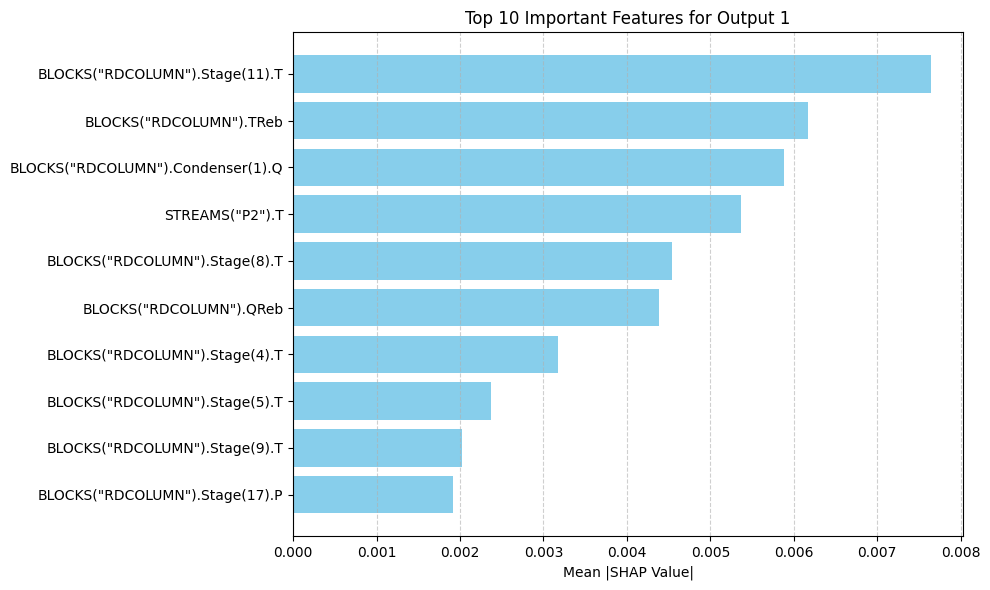

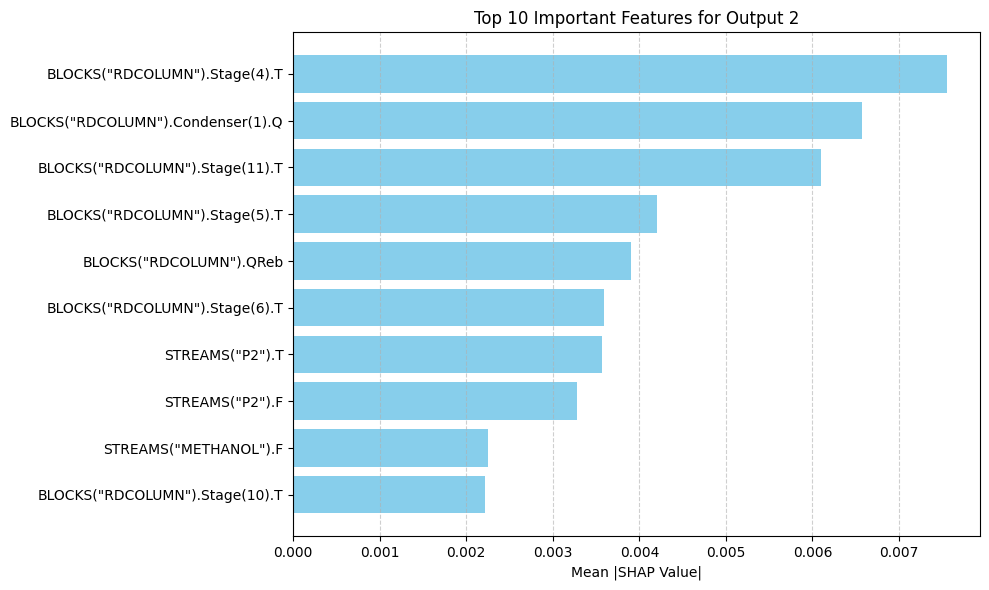

In [55]:
feature_names = df.drop(['STREAMS("P2").Zmn("METHY-01")','STREAMS("P1").Zmn("1-BUT-01")'], axis=1).columns
import matplotlib.pyplot as plt
import numpy as np

feature_names = df.drop(['STREAMS("P2").Zmn("METHY-01")','STREAMS("P1").Zmn("1-BUT-01")'], axis=1).columns

for output_index in range(y_test.shape[1]):
    # shap_values[:, :, output_index] خودش یک shap.Explanation هست که می‌تونیم .values روش اعمال کنیم
    shap_vals = shap_values[:, :, output_index].values  # shape: (samples, features)
    
    # میانگین قدر مطلق SHAP برای هر ویژگی
    mean_abs_shap = np.abs(shap_vals).mean(axis=0)
    
    # گرفتن 10 فیچر مهم
    top_indices = np.argsort(mean_abs_shap)[::-1][:10]
    top_features = feature_names[top_indices]
    top_values = mean_abs_shap[top_indices]
    
    # رسم بارپلات
    plt.figure(figsize=(10, 6))
    plt.barh(top_features[::-1], top_values[::-1], color='skyblue')
    plt.xlabel("Mean |SHAP Value|")
    plt.title(f"Top 10 Important Features for Output {output_index + 1}")
    plt.tight_layout()
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.show()